# imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.read_csv('../prepared/pooled_candidates.csv')['candidate_id'].nunique()


2721

# Base metrics

In [19]:
# answer
# all_judgments = pd.read_csv('all_judgments.csv')
all_judgments = pd.read_csv('../judgments_gpt_5_new/judgments_gpt_5_new.csv')
# gold subset of queries (40/160)
gold_subset = pd.read_csv('../prepared/gold_subset.csv')

queries = pd.read_csv('../prepared/queries.csv')

# retrieval results
# sql_hr small llm + bm25 + vectors
partial_results = pd.read_csv('../all_search_systems_concat/retrieval_results_dublicates.csv')
# sql hr big llm
sql_big_llm_res = pd.read_csv('../sql-hr/retrieval_sql_hr_bigger_llm_new.csv')
# rag agent search
rag_agent_res = pd.read_csv('../agent_rag/retrieval_rag_agent.csv')

In [4]:
queries.shape

(160, 6)

In [5]:
all_judgments[['query_id', 'candidate_id']].drop_duplicates().shape

(2719, 2)

In [6]:
all_judgments['candidate_id'].nunique()

1229

In [7]:
queries[['domain', 'query_type']].value_counts().unstack(fill_value=0)

query_type,complex,fuzzy,normal,strict
domain,,,,
backend,11,11,11,11
data,9,9,9,9
frontend,10,10,10,10
qa,10,10,10,10


In [8]:
gold_subset[['domain', 'query_type']].value_counts().unstack(fill_value=0)

query_type,complex,fuzzy,normal,strict
domain,,,,
backend,2,2,4,2
data,2,2,4,2
frontend,2,2,4,2
qa,2,2,4,2


In [9]:
all_retrieval_results = pd.concat([partial_results, sql_big_llm_res, rag_agent_res], ignore_index=True)

all_retrieval_results = all_retrieval_results.merge(gold_subset[['query_id', 'is_gold']], on='query_id', how='left')

final_df = all_retrieval_results.merge(
    all_judgments[['query_id', 'candidate_id', 'relevance_score', 'judge_comment']],
    on=['query_id', 'candidate_id'],
    how='left'
)

query_meta = queries[["query_id", "domain", "query_type", "job_title"]].drop_duplicates()
final_df = final_df.merge(query_meta, on="query_id", how="left", validate="many_to_one")


In [10]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11611 entries, 0 to 11610
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   query_id             11611 non-null  object 
 1   candidate_id         11611 non-null  object 
 2   search_system        11611 non-null  object 
 3   rank                 11611 non-null  float64
 4   score                11611 non-null  float64
 5   latency_ms           11611 non-null  float64
 6   retrieved_at         11611 non-null  object 
 7   latency_to_first_ms  2144 non-null   float64
 8   is_gold              2882 non-null   object 
 9   relevance_score      2882 non-null   float64
 10  judge_comment        2882 non-null   object 
 11  domain               11611 non-null  object 
 12  query_type           11611 non-null  object 
 13  job_title            11611 non-null  object 
dtypes: float64(5), object(9)
memory usage: 1.2+ MB


In [11]:
final_df.to_csv('final_results_all_retrieval_systems_new.csv', index=False)

In [12]:
final_df = pd.read_csv('final_results_all_retrieval_systems_new.csv')


In [13]:
distribution = (
    final_df.groupby(["search_system", "relevance_score"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[0, 1, 2], fill_value=0)
    .astype(int)
)
distribution

relevance_score,0,1,2
search_system,,,
agent_rag,451,54,95
bm25,564,22,14
sql_hr,398,74,92
sql_hr_big,323,56,139
vector,456,57,87


relevance_score    0   1    2
search_system                
bm25             564  22   14
vector           456  57   87
sql_hr           398  74   92
agent_rag        451  54   95
sql_hr_big       323  56  139


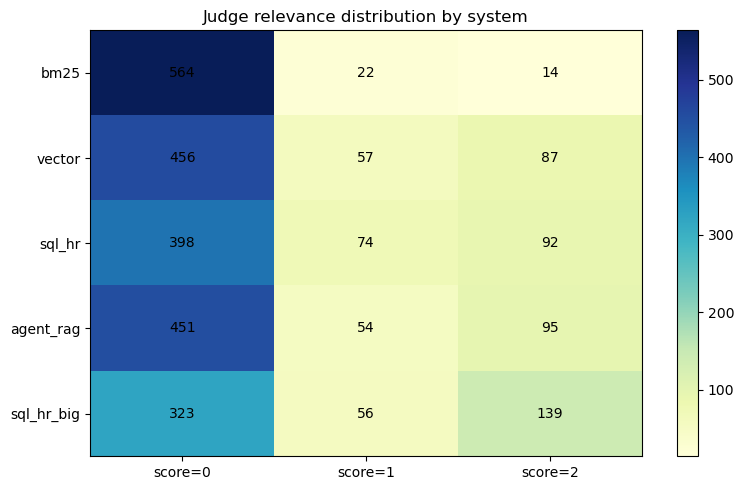

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

gold_df = final_df[final_df["is_gold"] == True].copy()
gold_df["relevance_score"] = gold_df["relevance_score"].fillna(-1)

# Абсолютные значения
heatmap_counts = (
    gold_df.groupby(["search_system", "relevance_score"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[0, 1, 2], fill_value=0)
)
heatmap_counts = heatmap_counts.sort_values(by=2, ascending=True)

print(heatmap_counts)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap_counts.values, aspect="auto", cmap="YlGnBu")

ax.set_xticks(range(len(heatmap_counts.columns)))
ax.set_xticklabels([f"score={c}" for c in heatmap_counts.columns])
ax.set_yticks(range(len(heatmap_counts.index)))
ax.set_yticklabels(heatmap_counts.index)

for i in range(heatmap_counts.shape[0]):
    for j in range(heatmap_counts.shape[1]):
        ax.text(j, i, str(heatmap_counts.iloc[i, j]), ha="center", va="center")

ax.set_title("Judge relevance distribution by system")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("graphics/heatmap_relevance_counts.png", dpi=200, bbox_inches="tight")
plt.show()

relevance_score    0   1    2
search_system                
bm25             564  22   14
vector           456  57   87
sql_hr           398  74   92
agent_rag        451  54   95
sql_hr_big       323  56  139


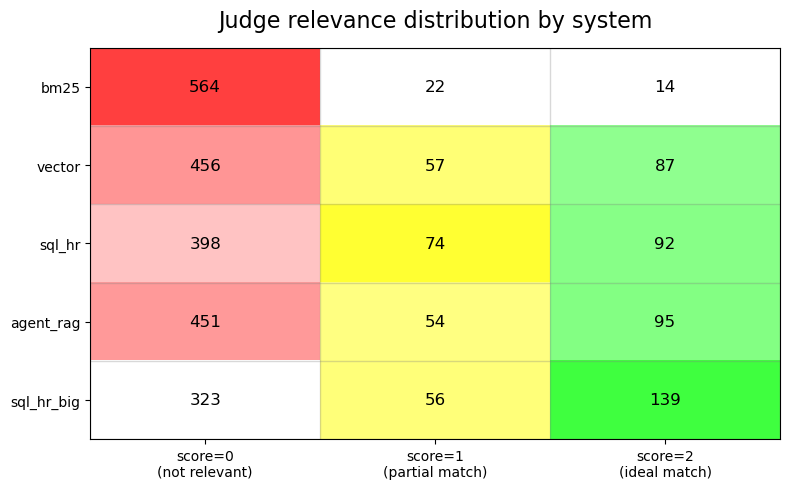

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

final_df = pd.read_csv('final_results_all_retrieval_systems_new.csv')


gold_df = final_df[final_df["is_gold"] == True].copy()
gold_df["relevance_score"] = gold_df["relevance_score"].fillna(-1)

# Считаем количества по системам
heatmap_counts = (
    gold_df.groupby(["search_system", "relevance_score"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[0, 1, 2], fill_value=0)
)

# Сортировка по возрастанию количества идеальных мэтчей
heatmap_counts = heatmap_counts.sort_values(by=2, ascending=True)

print(heatmap_counts)

# -----------------------------
# Нормализация по каждой колонке отдельно
# -----------------------------
norm_df = heatmap_counts.astype(float).copy()

for col in norm_df.columns:
    col_min = norm_df[col].min()
    col_max = norm_df[col].max()

    if col_max > col_min:
        norm_df[col] = (norm_df[col] - col_min) / (col_max - col_min)
    else:
        norm_df[col] = 0.5  # если вдруг все значения одинаковые

# -----------------------------
# RGB-матрица:
# score=0 -> красный (чем больше, тем хуже)
# score=1 -> желто-оранжевый (чем больше, тем лучше)
# score=2 -> зеленый (чем больше, тем лучше)
# -----------------------------
n_rows, n_cols = norm_df.shape
rgb = np.ones((n_rows, n_cols, 3))  # белая база

for i in range(n_rows):
    # score = 0  -> красный
    v0 = norm_df.iloc[i, 0]
    rgb[i, 0] = [1.0, 1.0 - 0.75 * v0, 1.0 - 0.75 * v0]

    # score = 1 -> желто-оранжевый
    v1 = norm_df.iloc[i, 1]
    rgb[i, 1] = [1.0, 1.0, 1.0 - 0.8 * v1]

    # score = 2 -> зеленый
    v2 = norm_df.iloc[i, 2]
    rgb[i, 2] = [1.0 - 0.75 * v2, 1.0, 1.0 - 0.75 * v2]

# -----------------------------
# Рисуем heatmap
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(rgb, aspect="auto")

ax.set_xticks(range(len(heatmap_counts.columns)))
ax.set_xticklabels(
    [
        "score=0\n(not relevant)",
        "score=1\n(partial match)",
        "score=2\n(ideal match)",
    ]
)

ax.set_yticks(range(len(heatmap_counts.index)))
ax.set_yticklabels(heatmap_counts.index)

# Подписываем абсолютные значения
for i in range(heatmap_counts.shape[0]):
    for j in range(heatmap_counts.shape[1]):
        value = heatmap_counts.iloc[i, j]
        ax.text(j, i, str(value), ha="center", va="center", fontsize=12, color="black")

ax.set_title("Judge relevance distribution by system", fontsize=16, pad=15)

# Добавим визуальные границы ячеек
ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
ax.grid(which="minor", color="gray", linestyle="-", linewidth=1, alpha=0.3)
ax.tick_params(which="minor", bottom=False, left=False)

plt.tight_layout()
plt.savefig("graphics/heatmap_relevance_custom_rgb.png", dpi=200, bbox_inches="tight")
plt.show()

# infographics and metrics 

In [5]:

# =========================
# Пути
# =========================

BASE = Path(".")

final_df_path = BASE / "final_results_all_retrieval_systems_new.csv"
all_judgments_path = BASE / "../judgments_gpt_5_new/judgments_gpt_5_new.csv"
gold_subset_path = BASE / "../prepared/gold_subset.csv"
queries_path = BASE / "../prepared/queries.csv"

out_dir = BASE / "metrics"
out_dir.mkdir(exist_ok=True)

# =========================
# Загрузка
# =========================
final_df = pd.read_csv(final_df_path)
all_judgments = pd.read_csv(all_judgments_path)
gold_subset = pd.read_csv(gold_subset_path)
queries = pd.read_csv(queries_path)

In [6]:
# =========================
# Подготовка
# =========================
gold_query_ids = set(gold_subset.loc[gold_subset["is_gold"] == True, "query_id"].unique())

# Оставляем только нужные колонки из judgments
judg_cols = ["query_id", "candidate_id", "relevance_score"]
all_judgments = all_judgments[judg_cols].copy()

# На случай дублей по одной и той же паре (query_id, candidate_id)
dup_cnt = all_judgments.duplicated(["query_id", "candidate_id"]).sum()
print("duplicates in all_judgments by (query_id, candidate_id):", dup_cnt)

if dup_cnt > 0:
    # если вдруг дубли есть, берем max relevance_score
    all_judgments = (
        all_judgments
        .groupby(["query_id", "candidate_id"], as_index=False)["relevance_score"]
        .max()
    )

duplicates in all_judgments by (query_id, candidate_id): 0


In [7]:

# Обогащаем final_df актуальной разметкой заново, чтобы ничего не потерять
base_cols = [c for c in final_df.columns if c not in ["relevance_score", "judge_comment"]]
final_df = final_df[base_cols].merge(
    all_judgments,
    on=["query_id", "candidate_id"],
    how="left",
    validate="many_to_one"
)

# Добавим query metadata для красивых срезов
query_meta = queries[["query_id", "domain", "query_type", "job_title"]].drop_duplicates()
final_df = final_df.merge(query_meta, on="query_id", how="left", validate="many_to_one")

# Приведем флаг gold
final_df["is_gold"] = final_df["is_gold"].fillna(False).astype(bool)

# =========================
# Quality-часть: только gold queries
# =========================
gold_results = final_df[final_df["query_id"].isin(gold_query_ids)].copy()

coverage = (
    gold_results.assign(is_judged=gold_results["relevance_score"].notna())
    .groupby("search_system", as_index=False)
    .agg(
        total_rows=("candidate_id", "size"),
        judged_rows=("is_judged", "sum")
    )
)
coverage["judged_coverage"] = (coverage["judged_rows"] / coverage["total_rows"]).round(4)

print("\n=== Gold coverage by system ===")
print(coverage.sort_values("search_system"))

coverage.to_csv(out_dir / "gold_coverage_by_system.csv", index=False)


=== Gold coverage by system ===
  search_system  total_rows  judged_rows  judged_coverage
0     agent_rag         600          600              1.0
1          bm25         600          600              1.0
2        sql_hr         564          564              1.0
3    sql_hr_big         518          518              1.0
4        vector         600          600              1.0


/var/folders/3y/9g66ffzn3pqgvjmly0907bcr0000gn/T/ipykernel_58210/3131571544.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_df["is_gold"] = final_df["is_gold"].fillna(False).astype(bool)


In [8]:

# =========================
# Вспомогательные функции
# =========================
def dcg_at_k(rels, k):
    rels = np.asarray(rels[:k], dtype=float)
    if len(rels) == 0:
        return 0.0
    discounts = 1.0 / np.log2(np.arange(2, len(rels) + 2))
    gains = (2 ** rels - 1)
    return float(np.sum(gains * discounts))

def precision_at_k(binary_rels, k):
    topk = np.asarray(binary_rels[:k], dtype=float)
    if len(topk) < k:
        topk = np.pad(topk, (0, k - len(topk)), constant_values=0)
    return float(np.sum(topk) / k)

def recall_at_k(binary_rels, total_relevant, k):
    if total_relevant == 0:
        return 0.0
    topk = np.asarray(binary_rels[:k], dtype=float)
    return float(np.sum(topk) / total_relevant)

def compute_metrics_for_system(
    system_df,
    gold_query_ids,
    relevant_counts_by_query,
    ideal_dcg_by_query,
    relevance_threshold=1,
    ks=(5, 10),
):
    rows = []

    for qid in sorted(gold_query_ids):
        qdf = system_df[system_df["query_id"] == qid].sort_values("rank")
        rels = qdf["relevance_score"].fillna(0).tolist()
        binary_rels = [1 if r >= relevance_threshold else 0 for r in rels]

        row = {"query_id": qid}

        total_relevant = relevant_counts_by_query.get(qid, 0)

        for k in ks:
            row[f"precision@{k}"] = precision_at_k(binary_rels, k)
            row[f"recall@{k}"] = recall_at_k(binary_rels, total_relevant, k)

            dcg = dcg_at_k(rels, k)
            idcg = ideal_dcg_by_query.get((qid, k), 0.0)
            row[f"ndcg@{k}"] = (dcg / idcg) if idcg > 0 else 0.0

        rows.append(row)

    return pd.DataFrame(rows)

In [9]:

# =========================
# Подготовка "идеальных" знаменателей по all_judgments
# Recall denominator = количество релевантных кандидатов в judged pool на query
# nDCG denominator = идеальная сортировка judged pool на query
# =========================
gold_judgments = all_judgments[all_judgments["query_id"].isin(gold_query_ids)].copy()

RELEVANCE_THRESHOLD = 1
KS = (5, 10)

relevant_counts_by_query = (
    gold_judgments.assign(is_relevant=gold_judgments["relevance_score"] >= RELEVANCE_THRESHOLD)
    .groupby("query_id")["is_relevant"]
    .sum()
    .to_dict()
)

ideal_dcg_by_query = {}
for qid, qdf in gold_judgments.groupby("query_id"):
    ideal_rels = sorted(qdf["relevance_score"].tolist(), reverse=True)
    for k in KS:
        ideal_dcg_by_query[(qid, k)] = dcg_at_k(ideal_rels, k)

# =========================
# Метрики по системам
# =========================
systems_order = ["bm25", "vector", "sql_hr", "sql_hr_big", "agent_rag"]
existing_systems = [s for s in systems_order if s in gold_results["search_system"].unique()]

per_query_metrics = []
summary_metrics = []

for system in existing_systems:
    system_df = gold_results[gold_results["search_system"] == system].copy()

    system_query_metrics = compute_metrics_for_system(
        system_df=system_df,
        gold_query_ids=gold_query_ids,
        relevant_counts_by_query=relevant_counts_by_query,
        ideal_dcg_by_query=ideal_dcg_by_query,
        relevance_threshold=RELEVANCE_THRESHOLD,
        ks=KS,
    )

    system_query_metrics["search_system"] = system
    per_query_metrics.append(system_query_metrics)

    metric_cols = [c for c in system_query_metrics.columns if c.startswith(("precision@", "recall@", "ndcg@"))]
    summary_row = {"search_system": system}
    for col in metric_cols:
        summary_row[col] = system_query_metrics[col].mean()

    summary_metrics.append(summary_row)

per_query_metrics_df = pd.concat(per_query_metrics, ignore_index=True)
metrics_summary_df = pd.DataFrame(summary_metrics)

# Красивое округление
metric_cols = [c for c in metrics_summary_df.columns if c != "search_system"]
metrics_summary_df[metric_cols] = metrics_summary_df[metric_cols].round(4)

print("\n=== Metrics summary ===")
print(metrics_summary_df.sort_values("search_system"))

per_query_metrics_df.to_csv(out_dir / "per_query_metrics.csv", index=False)
metrics_summary_df.to_csv(out_dir / "metrics_summary.csv", index=False)


=== Metrics summary ===
  search_system  precision@5  recall@5  ndcg@5  precision@10  recall@10  \
4     agent_rag        0.310    0.0950  0.2540        0.2750     0.1572   
0          bm25        0.035    0.0188  0.0372        0.0475     0.0419   
2        sql_hr        0.355    0.1398  0.2920        0.3075     0.2542   
3    sql_hr_big        0.425    0.1521  0.3813        0.3500     0.2599   
1        vector        0.305    0.0910  0.2517        0.2750     0.1532   

   ndcg@10  
4   0.2571  
0   0.0476  
2   0.3131  
3   0.3822  
1   0.2467  


In [10]:
metrics_summary_df.to_excel('check.xlsx', index=False)

In [23]:

# =========================
# Relevance distribution for slides
# =========================
relevance_distribution = (
    gold_results.groupby(["search_system", "relevance_score"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[0, 1, 2], fill_value=0)
    .astype(int)
    .reset_index()
)

print("\n=== Relevance distribution ===")
print(relevance_distribution)

relevance_distribution.to_csv(out_dir / "relevance_distribution.csv", index=False)

# =========================
# Latency / TTFT summary
# Важно: latency считаем по query-level, а не по 15 одинаковым строкам выдачи
# =========================
latency_cols = ["search_system", "query_id", "latency_ms"]
if "latency_to_first_ms" in final_df.columns:
    latency_cols.append("latency_to_first_ms")

latency_per_query = final_df[latency_cols].drop_duplicates(subset=["search_system", "query_id"]).copy()

def p95(x):
    return float(np.percentile(x, 95)) if len(x) > 0 else np.nan

latency_summary = (
    latency_per_query.groupby("search_system", as_index=False)
    .agg(
        n_queries=("query_id", "nunique"),
        mean_latency_ms=("latency_ms", "mean"),
        median_latency_ms=("latency_ms", "median"),
        p95_latency_ms=("latency_ms", p95),
    )
)

if "latency_to_first_ms" in latency_per_query.columns:
    ttft_summary = (
        latency_per_query.groupby("search_system", as_index=False)
        .agg(
            mean_latency_to_first_ms=("latency_to_first_ms", "mean"),
            median_latency_to_first_ms=("latency_to_first_ms", "median"),
            p95_latency_to_first_ms=("latency_to_first_ms", p95),
        )
    )
    latency_summary = latency_summary.merge(ttft_summary, on="search_system", how="left")

latency_summary = latency_summary.round(2)

print("\n=== Latency summary ===")
print(latency_summary.sort_values("search_system"))

latency_per_query.to_csv(out_dir / "latency_per_query.csv", index=False)
latency_summary.to_csv(out_dir / "latency_summary.csv", index=False)


=== Relevance distribution ===
relevance_score search_system    0   1    2
0                   agent_rag  451  54   95
1                        bm25  564  22   14
2                      sql_hr  398  74   92
3                  sql_hr_big  323  56  139
4                      vector  456  57   87

=== Latency summary ===
  search_system  n_queries  mean_latency_ms  median_latency_ms  \
0     agent_rag        160         24474.28           24283.35   
1          bm25        160           447.81             450.31   
2        sql_hr        157        129779.89          120786.00   
3    sql_hr_big        159         19427.39           18926.00   
4        vector        160             0.27               0.25   

   p95_latency_ms  mean_latency_to_first_ms  median_latency_to_first_ms  \
0        33134.24                       NaN                         NaN   
1          695.17                       NaN                         NaN   
2       181501.20                       NaN              

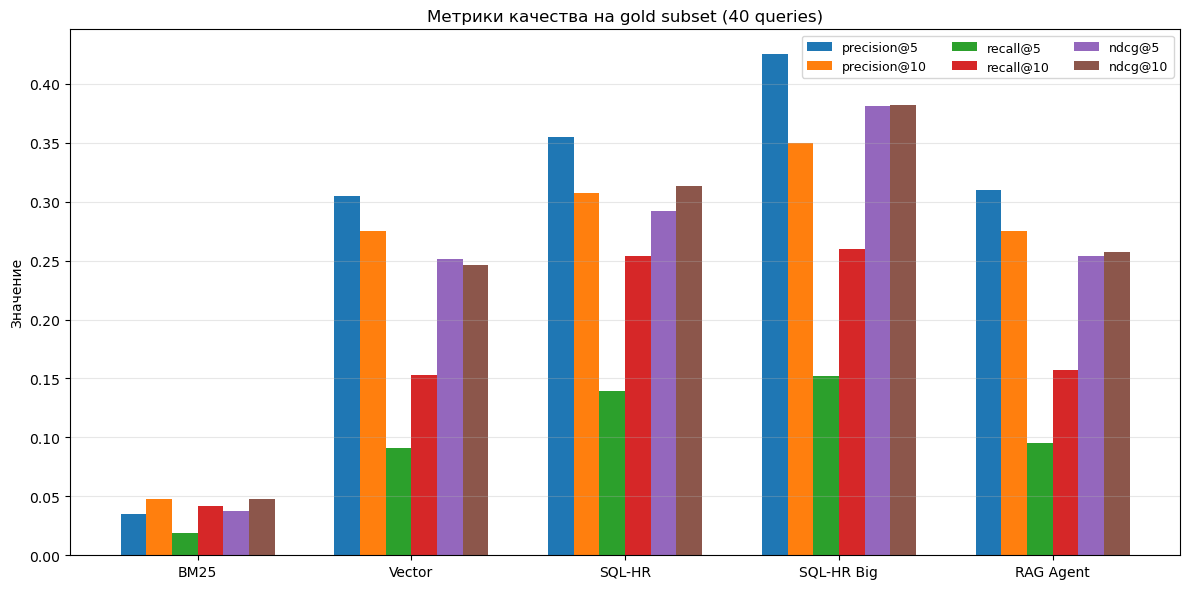

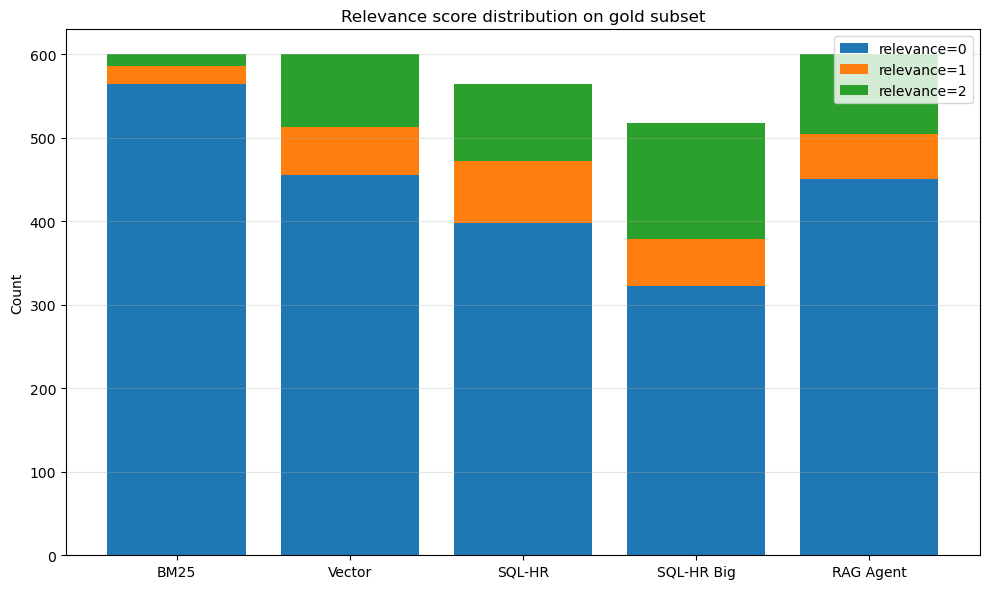

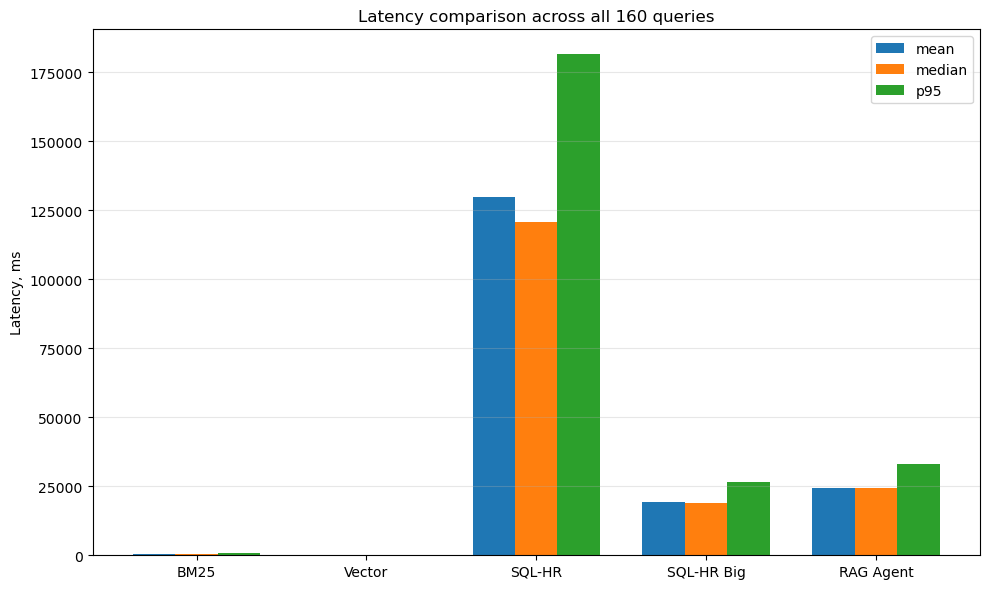

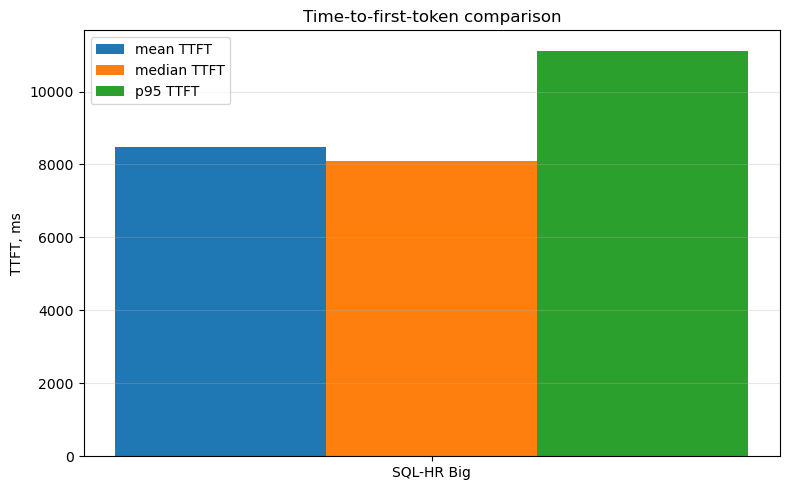

/var/folders/3y/9g66ffzn3pqgvjmly0907bcr0000gn/T/ipykernel_47772/2915009379.py:167: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)


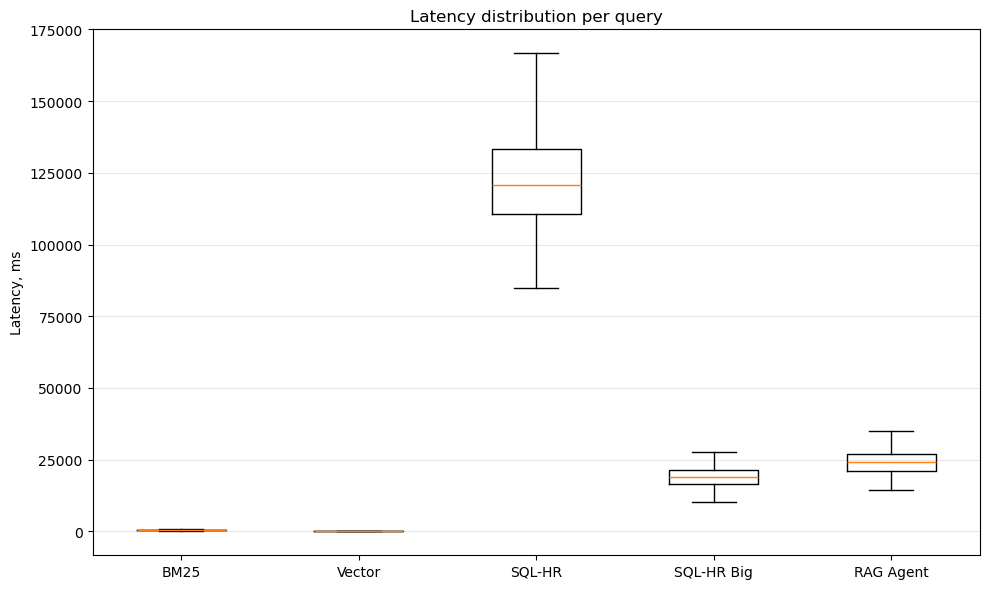

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Читаем уже посчитанные summary
# =========================
metrics_summary_df = pd.read_csv("metrics/metrics_summary.csv")
latency_summary = pd.read_csv("metrics/latency_summary.csv")
relevance_distribution = pd.read_csv("metrics/relevance_distribution.csv")
latency_per_query = pd.read_csv("metrics/latency_per_query.csv")
per_query_metrics_df = pd.read_csv("metrics/per_query_metrics.csv")

label_map = {
    "bm25": "BM25",
    "vector": "Vector",
    "sql_hr": "SQL-HR",
    "sql_hr_big": "SQL-HR Big",
    "agent_rag": "RAG Agent",
}

system_order = ["bm25", "vector", "sql_hr", "sql_hr_big", "agent_rag"]

# Упорядочим
metrics_summary_df["search_system"] = pd.Categorical(
    metrics_summary_df["search_system"], categories=system_order, ordered=True
)
metrics_summary_df = metrics_summary_df.sort_values("search_system")

latency_summary["search_system"] = pd.Categorical(
    latency_summary["search_system"], categories=system_order, ordered=True
)
latency_summary = latency_summary.sort_values("search_system")

relevance_distribution["search_system"] = pd.Categorical(
    relevance_distribution["search_system"], categories=system_order, ordered=True
)
relevance_distribution = relevance_distribution.sort_values("search_system")

latency_per_query["search_system"] = pd.Categorical(
    latency_per_query["search_system"], categories=system_order, ordered=True
)
latency_per_query = latency_per_query.sort_values("search_system")

# Подписи
metrics_summary_df["label"] = metrics_summary_df["search_system"].map(label_map)
latency_summary["label"] = latency_summary["search_system"].map(label_map)
relevance_distribution["label"] = relevance_distribution["search_system"].map(label_map)
latency_per_query["label"] = latency_per_query["search_system"].map(label_map)

# =========================
# 1. График quality metrics
# =========================
quality_cols = ["precision@5", "precision@10", "recall@5", "recall@10", "ndcg@5", "ndcg@10"]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics_summary_df))
bar_width = 0.12

for i, col in enumerate(quality_cols):
    ax.bar(
        x + i * bar_width,
        metrics_summary_df[col],
        width=bar_width,
        label=col
    )

ax.set_xticks(x + bar_width * (len(quality_cols) - 1) / 2)
ax.set_xticklabels(metrics_summary_df["label"], rotation=0)
ax.set_ylabel("Значение")
ax.set_title("Метрики качества на gold subset (40 queries)")
ax.legend(ncol=3, fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("graphics/plot_quality_metrics.png", dpi=200, bbox_inches="tight")
plt.show()

# =========================
# 2. Relevance distribution stacked bar
# =========================
fig, ax = plt.subplots(figsize=(10, 6))

bottom = np.zeros(len(relevance_distribution))
for rel in [0, 1, 2]:
    vals = relevance_distribution[str(rel)] if str(rel) in relevance_distribution.columns else relevance_distribution[rel]
    ax.bar(relevance_distribution["label"], vals, bottom=bottom, label=f"relevance={rel}")
    bottom += vals.to_numpy()

ax.set_ylabel("Count")
ax.set_title("Relevance score distribution on gold subset")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("graphics/plot_relevance_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

# =========================
# 3. Latency summary bar chart
# =========================
latency_plot_df = latency_summary.copy()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(latency_plot_df))
bar_width = 0.25

ax.bar(x - bar_width, latency_plot_df["mean_latency_ms"], width=bar_width, label="mean")
ax.bar(x, latency_plot_df["median_latency_ms"], width=bar_width, label="median")
ax.bar(x + bar_width, latency_plot_df["p95_latency_ms"], width=bar_width, label="p95")

ax.set_xticks(x)
ax.set_xticklabels(latency_plot_df["label"])
ax.set_ylabel("Latency, ms")
ax.set_title("Latency comparison across all 160 queries")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("graphics/plot_latency_summary.png", dpi=200, bbox_inches="tight")
plt.show()

# =========================
# 4. TTFT comparison (только где есть latency_to_first_ms)
# =========================
ttft_cols = [
    "mean_latency_to_first_ms",
    "median_latency_to_first_ms",
    "p95_latency_to_first_ms",
]
ttft_existing = [c for c in ttft_cols if c in latency_summary.columns]

ttft_df = latency_summary.dropna(subset=ttft_existing, how="all").copy()

if not ttft_df.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(ttft_df))
    bar_width = 0.25

    if "mean_latency_to_first_ms" in ttft_df.columns:
        ax.bar(x - bar_width, ttft_df["mean_latency_to_first_ms"], width=bar_width, label="mean TTFT")
    if "median_latency_to_first_ms" in ttft_df.columns:
        ax.bar(x, ttft_df["median_latency_to_first_ms"], width=bar_width, label="median TTFT")
    if "p95_latency_to_first_ms" in ttft_df.columns:
        ax.bar(x + bar_width, ttft_df["p95_latency_to_first_ms"], width=bar_width, label="p95 TTFT")

    ax.set_xticks(x)
    ax.set_xticklabels(ttft_df["label"])
    ax.set_ylabel("TTFT, ms")
    ax.set_title("Time-to-first-token comparison")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("graphics/plot_ttft_summary.png", dpi=200, bbox_inches="tight")
    plt.show()

# =========================
# 5. Boxplot latency per query
# =========================
fig, ax = plt.subplots(figsize=(10, 6))

data = []
labels = []
for system in system_order:
    vals = latency_per_query.loc[latency_per_query["search_system"] == system, "latency_ms"].dropna().values
    if len(vals) > 0:
        data.append(vals)
        labels.append(label_map[system])

ax.boxplot(data, labels=labels, showfliers=False)
ax.set_ylabel("Latency, ms")
ax.set_title("Latency distribution per query")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("graphics/plot_latency_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()